# Chapter 104 — Wave Functions

> **Prerequisites:** ch102 (Sine and Cosine), ch103 (Unit Circle)
>
> **Outcomes:** Model waves with sinusoidal functions; Decompose signals into frequency components; Connect to Fourier analysis


## Sinusoidal Waves

A general sinusoidal wave: **y(t) = A·sin(2π·f·t + φ) + C**
- A: amplitude (peak value)
- f: frequency in Hz (cycles per second); ω = 2πf is angular frequency
- φ: phase (horizontal shift in radians)
- C: vertical offset (DC component)

**Period:** T = 1/f — time for one complete cycle
**Wavelength:** λ = v/f for wave speed v

**Superposition:** waves add linearly. Two sinusoids of different frequencies:
y(t) = sin(t) + 0.5·sin(3t)
This is the beginning of Fourier analysis — any periodic function = sum of sinusoids.

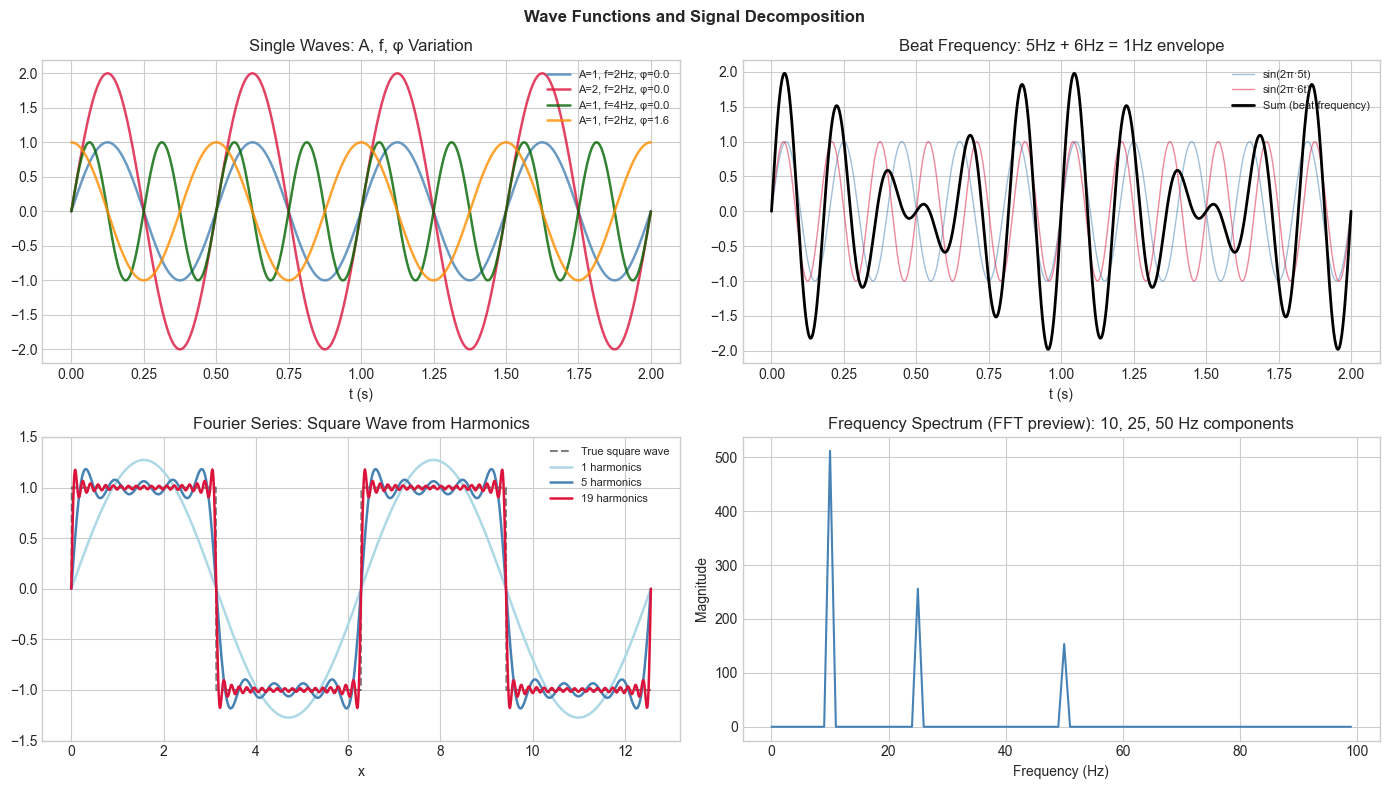

In [1]:
# --- Wave analysis and superposition ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

t = np.linspace(0, 2, 1000)  # 2 seconds

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Single wave parameters
ax = axes[0,0]
for A, f, phi, color in [(1,2,0,'steelblue'),(2,2,0,'crimson'),(1,4,0,'darkgreen'),(1,2,np.pi/2,'darkorange')]:
    ax.plot(t, A*np.sin(2*np.pi*f*t + phi), color=color, lw=1.8, alpha=0.8,
            label=f'A={A}, f={f}Hz, φ={phi:.1f}')
ax.set_title('Single Waves: A, f, φ Variation'); ax.legend(fontsize=8); ax.set_xlabel('t (s)')

# Wave superposition → beat frequency
f1, f2 = 5, 6  # close frequencies
y1 = np.sin(2*np.pi*f1*t)
y2 = np.sin(2*np.pi*f2*t)
axes[0,1].plot(t, y1, 'steelblue', lw=1, alpha=0.5, label=f'sin(2π·{f1}t)')
axes[0,1].plot(t, y2, 'crimson', lw=1, alpha=0.5, label=f'sin(2π·{f2}t)')
axes[0,1].plot(t, y1+y2, 'black', lw=2, label='Sum (beat frequency)')
axes[0,1].set_title(f'Beat Frequency: {f1}Hz + {f2}Hz = {abs(f1-f2)}Hz envelope')
axes[0,1].legend(fontsize=8); axes[0,1].set_xlabel('t (s)')

# Square wave from harmonics
x_sq = np.linspace(0, 4*np.pi, 1000)
square = np.zeros_like(x_sq)
ax = axes[1,0]
for n in range(1, 20, 2):  # odd harmonics
    component = (4/np.pi) * (1/n) * np.sin(n*x_sq)
    square += component
ax.plot(x_sq, np.sign(np.sin(x_sq)), 'k--', lw=1.5, alpha=0.5, label='True square wave')
for n_terms, color in [(1,'lightblue'),(5,'steelblue'),(19,'crimson')]:
    partial = sum((4/np.pi)*(1/n)*np.sin(n*x_sq) for n in range(1,n_terms*2,2))
    ax.plot(x_sq, partial, color=color, lw=1.8, label=f'{n_terms} harmonics')
ax.set_ylim(-1.5,1.5); ax.set_title('Fourier Series: Square Wave from Harmonics')
ax.legend(fontsize=8); ax.set_xlabel('x')

# Frequency content (DFT preview)
t_sig = np.linspace(0, 1, 1024, endpoint=False)
signal = np.sin(2*np.pi*10*t_sig) + 0.5*np.sin(2*np.pi*25*t_sig) + 0.3*np.sin(2*np.pi*50*t_sig)
freqs = np.fft.rfftfreq(len(t_sig), 1/1024)
magnitudes = np.abs(np.fft.rfft(signal))
axes[1,1].plot(freqs[:100], magnitudes[:100], color='steelblue', lw=1.5)
axes[1,1].set_title('Frequency Spectrum (FFT preview): 10, 25, 50 Hz components')
axes[1,1].set_xlabel('Frequency (Hz)'); axes[1,1].set_ylabel('Magnitude')

plt.suptitle('Wave Functions and Signal Decomposition', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Summary

- Wave: y(t) = A·sin(2πft + φ) — amplitude, frequency, phase fully characterize it
- Beat frequency: two close frequencies produce amplitude modulation at difference frequency
- Any periodic signal = sum of sinusoids (Fourier series)
- FFT decomposes a signal into its frequency components in O(n log n)

**Forward:** Full Fourier analysis in ch219 (Taylor Series/Approximation); FFT in ch176 (SVD chapter touches DFT).